<a href="https://colab.research.google.com/github/DibyenduBaner123/Disaster_Management_App/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
df = pd.read_csv("automobile_sales.csv")
years = list(range(2010, 2021))
vehicle_types = ["Sedan", "SUV", "Truck", "Sports"]

rows = []

for year in years:
    for month in range(1, 13):
        recession = 1 if year in [2010, 2011, 2020] else 0

        for vehicle in vehicle_types:
            base_sales = {
                "Sedan": 12000,
                "SUV": 10000,
                "Truck": 8500,
                "Sports": 6000
            }[vehicle]

            seasonal = 1 + 0.15 * np.sin(2 * np.pi * month / 12)

            sales = base_sales * seasonal
            sales *= 0.85 if recession else 1.0
            sales *= np.random.uniform(0.9, 1.1)

            advertising = sales * np.random.uniform(0.08, 0.15)
            price = {
                "Sedan": 25000,
                "SUV": 35000,
                "Truck": 40000,
                "Sports": 50000
            }[vehicle] * np.random.uniform(0.95, 1.05)

            gdp = 50000 + (year - 2010) * 2500
            gdp *= 0.92 if recession else 1
            gdp *= np.random.uniform(0.98, 1.02)

            unemployment = 9 if recession else 5
            unemployment += np.random.uniform(-0.7, 0.7)

            rows.append([
                f"{year}-{month:02d}-01",
                year,
                month,
                round(sales, 2),
                vehicle,
                round(advertising, 2),
                round(gdp, 2),
                recession,
                round(price, 2),
                round(unemployment, 2)
            ])

df = pd.DataFrame(rows, columns=[
    "Date",
    "Year",
    "Month",
    "Automobile_Sales",
    "Vehicle_Type",
    "Advertising_Expenditure",
    "GDP",
    "Recession",
    "Price",
    "Unemployment_Rate"
])

df.to_csv("automobile_sales.csv", index=False)

df.head()

,Date,Year,Month,Automobile_Sales,Vehicle_Type,Advertising_Expenditure,GDP,Recession,Price,Unemployment_Rate
0,2010-01-01,2010,1,10689.87,Sedan,1566.60,46181.53,1,25579.98,8.52
1,2010-01-01,2010,1,8508.83,SUV,715.30,46186.05,1,36281.62,9.29
2,2010-01-01,2010,1,7022.16,Truck,1038.53,45470.70,1,41329.77,8.55
3,2010-01-01,2010,1,5135.35,Sports,520.20,45874.78,1,50123.78,8.71
4,2010-02-01,2010,2,11782.84,Sedan,1057.68,45754.11,1,24480.36,8.94


In [2]:
df = pd.read_csv("automobile_sales.csv")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Load dataset
df = pd.read_csv("automobile_sales.csv")

# Display data
display(df.head())
display(df.info())

,Date,Year,Month,Automobile_Sales,Vehicle_Type,Advertising_Expenditure,GDP,Recession,Price,Unemployment_Rate
0,2010-01-01,2010,1,10689.87,Sedan,1566.60,46181.53,1,25579.98,8.52
1,2010-01-01,2010,1,8508.83,SUV,715.30,46186.05,1,36281.62,9.29
2,2010-01-01,2010,1,7022.16,Truck,1038.53,45470.70,1,41329.77,8.55
3,2010-01-01,2010,1,5135.35,Sports,520.20,45874.78,1,50123.78,8.71
4,2010-02-01,2010,2,11782.84,Sedan,1057.68,45754.11,1,24480.36,8.94


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     528 non-null    object 
 1   Year                     528 non-null    int64  
 2   Month                    528 non-null    int64  
 3   Automobile_Sales         528 non-null    float64
 4   Vehicle_Type             528 non-null    object 
 5   Advertising_Expenditure  528 non-null    float64
 6   GDP                      528 non-null    float64
 7   Recession                528 non-null    int64  
 8   Price                    528 non-null    float64
 9   Unemployment_Rate        528 non-null    float64
dtypes: float64(5), int64(3), object(2)
memory usage: 41.4+ KB


None

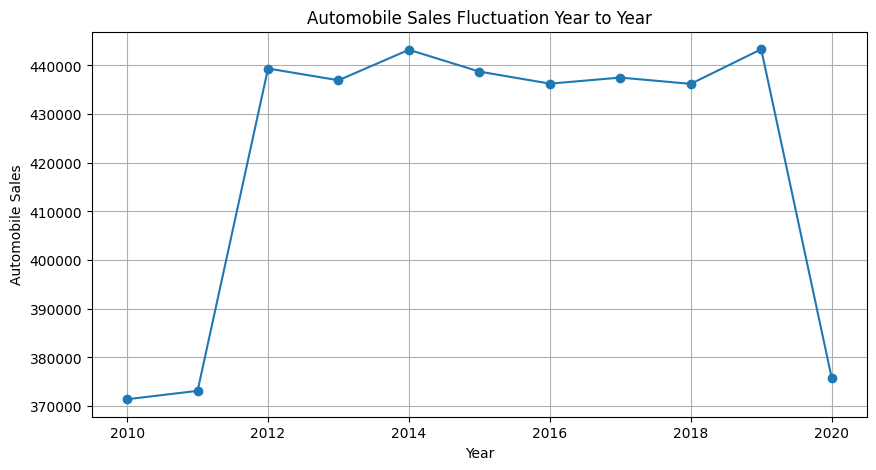

In [4]:
yearly_sales = df.groupby("Year")["Automobile_Sales"].sum()

plt.figure(figsize=(10, 5))
plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o"
)

plt.title("Automobile Sales Fluctuation Year to Year")
plt.xlabel("Year")
plt.ylabel("Automobile Sales")
plt.grid(True)
plt.show()

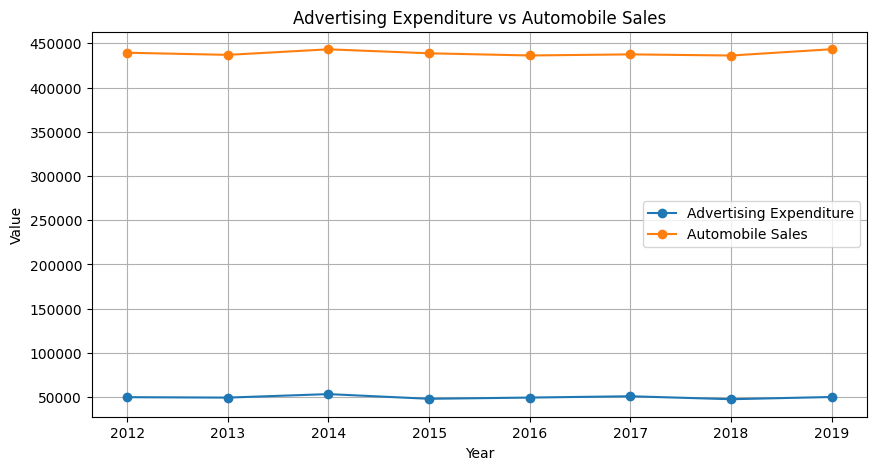

In [5]:
non_recession = df[df["Recession"] == 0]

result = non_recession.groupby("Year")[
    ["Advertising_Expenditure", "Automobile_Sales"]
].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    result.index,
    result["Advertising_Expenditure"],
    marker="o",
    label="Advertising Expenditure"
)

plt.plot(
    result.index,
    result["Automobile_Sales"],
    marker="o",
    label="Automobile Sales"
)

plt.title("Advertising Expenditure vs Automobile Sales")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

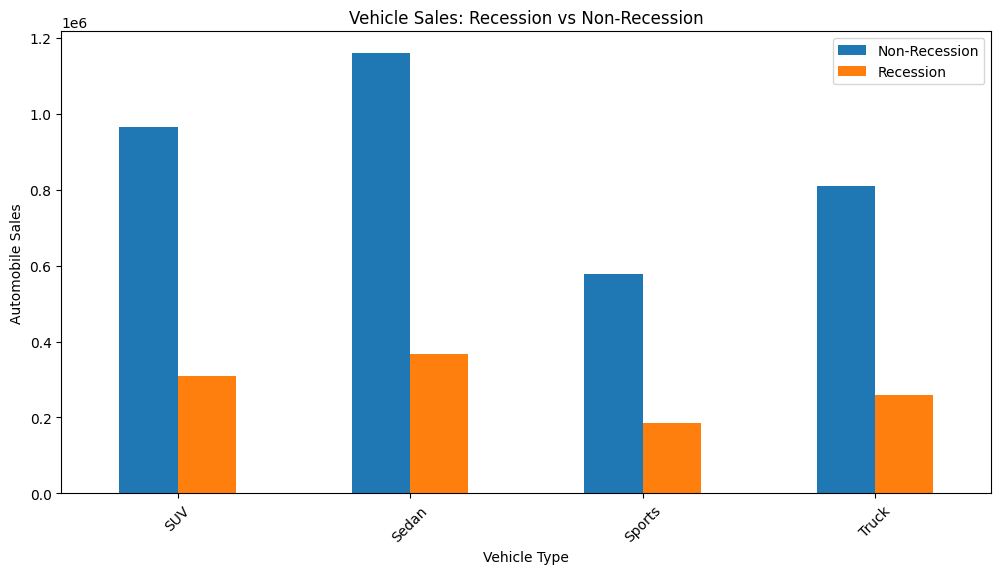

In [6]:
vehicle_sales = df.groupby(
    ["Vehicle_Type", "Recession"]
)["Automobile_Sales"].sum().unstack()

vehicle_sales.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Vehicle Sales: Recession vs Non-Recession")
plt.xlabel("Vehicle Type")
plt.ylabel("Automobile Sales")
plt.xticks(rotation=45)
plt.legend(
    ["Non-Recession", "Recession"]
)
plt.show()

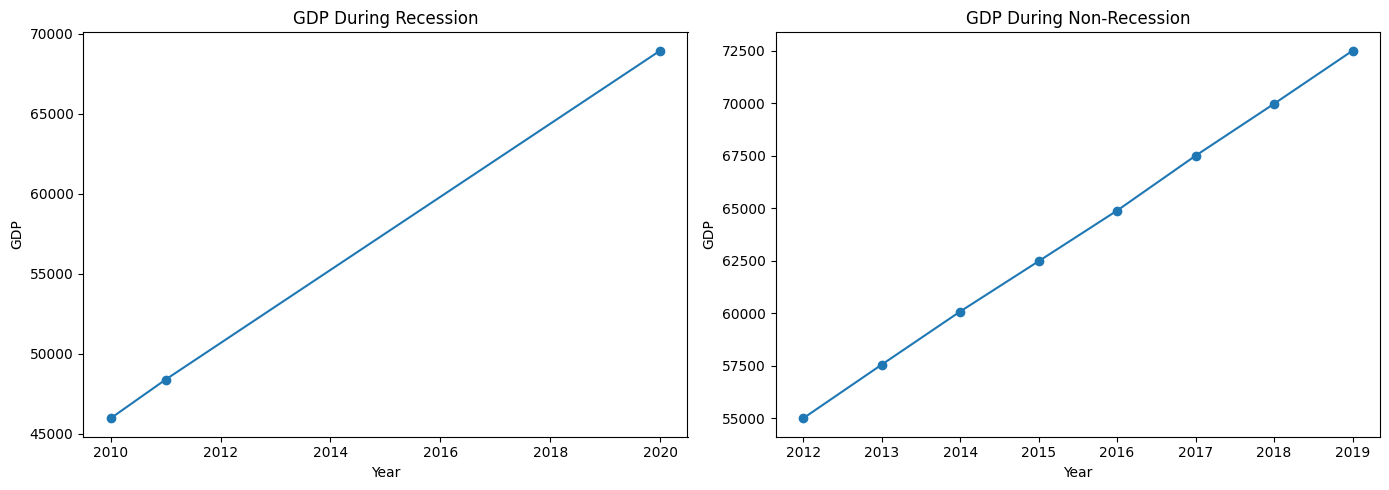

In [7]:
recession = df[df["Recession"] == 1]
non_recession = df[df["Recession"] == 0]

recession_gdp = recession.groupby("Year")["GDP"].mean()
non_recession_gdp = non_recession.groupby("Year")["GDP"].mean()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(
    recession_gdp.index,
    recession_gdp.values,
    marker="o"
)

ax[0].set_title("GDP During Recession")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("GDP")

ax[1].plot(
    non_recession_gdp.index,
    non_recession_gdp.values,
    marker="o"
)

ax[1].set_title("GDP During Non-Recession")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("GDP")

plt.tight_layout()
plt.show()

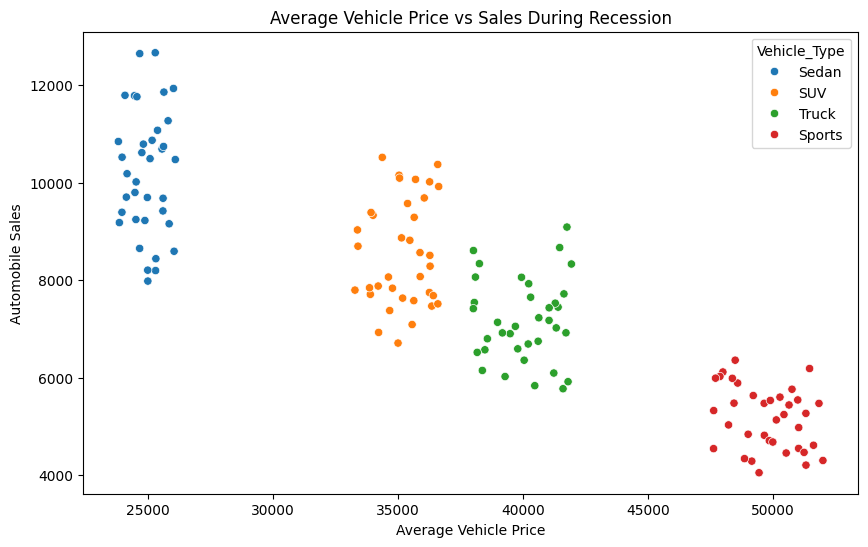

In [8]:
recession_data = df[df["Recession"] == 1]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=recession_data,
    x="Price",
    y="Automobile_Sales",
    hue="Vehicle_Type"
)

plt.title(
    "Average Vehicle Price vs Sales During Recession"
)
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.show()

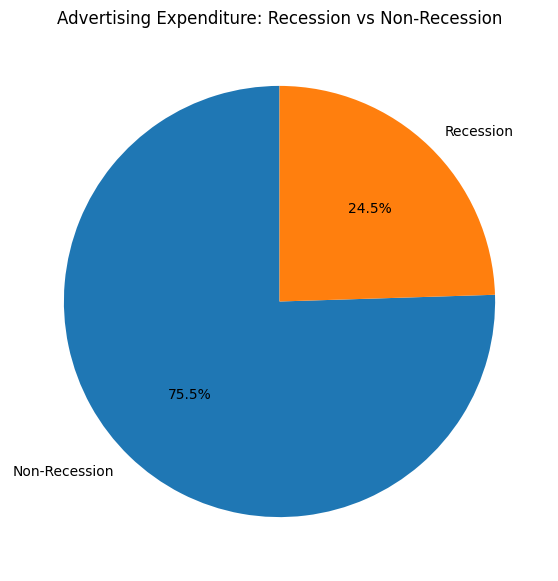

In [9]:
advertising = df.groupby("Recession")[
    "Advertising_Expenditure"
].sum()

plt.figure(figsize=(7, 7))

plt.pie(
    advertising.values,
    labels=["Non-Recession", "Recession"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Advertising Expenditure: Recession vs Non-Recession"
)

plt.show()

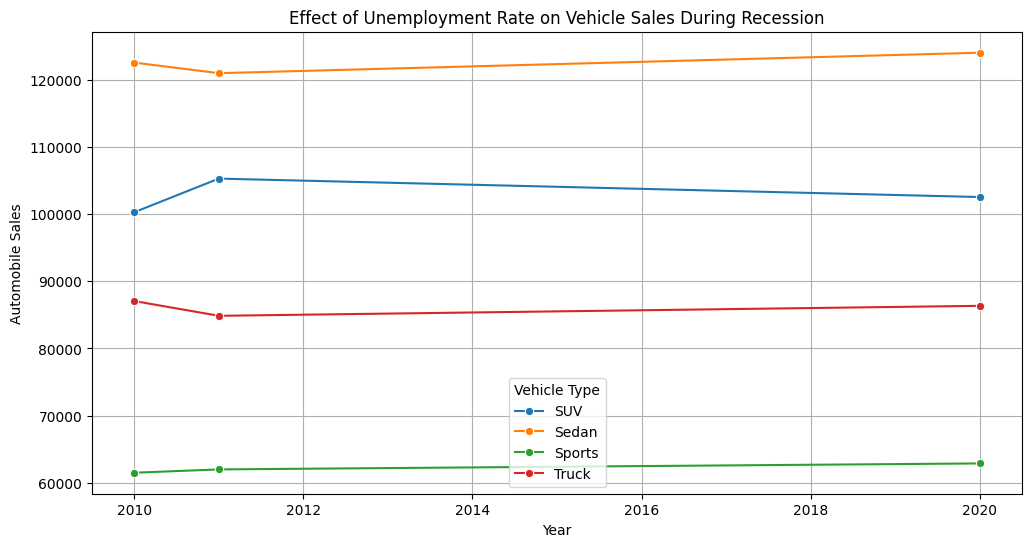

In [10]:
recession_data = df[df["Recession"] == 1]

sales_unemployment = recession_data.groupby(
    ["Year", "Vehicle_Type"]
)["Automobile_Sales"].sum().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=sales_unemployment,
    x="Year",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    marker="o"
)

plt.title(
    "Effect of Unemployment Rate on Vehicle Sales During Recession"
)

plt.xlabel("Year")
plt.ylabel("Automobile Sales")
plt.legend(title="Vehicle Type")
plt.grid(True)
plt.show()